<a href="https://colab.research.google.com/github/EugOT/CN-pr-MDD-snRNA-seq/blob/philipp/notebooks/joint_analysis_filtering_on_pv_neurons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#!git clone https://github.com/EugOT/CN-pr-MDD-snRNA-seq.git
#%cd /content/CN-pr-MDD-snRNA-seq/

In [4]:
#import shit, commented our what didn't work for now
import os
import random
import pacmap
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc #for analyzing single-cell gene expression data built jointly with anndata
import decoupler as dc
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from anndata.experimental.multi_files import AnnCollection

In [5]:
#make style adjustments. Why???
matplotlib.rcParams["pdf.use14corefonts"] = True
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica"]
matplotlib.rcParams["figure.max_open_warning"] = 20000

In [6]:
reseed = 42 #good choice 
random.seed(reseed) # seed to get consistent random numbers
np.random.seed(reseed) # should yield different random numbers than random.seed. Has more functions. Let's see if useful.

sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.settings.figdir = PLOTS_DIR
sc.settings.set_figure_params(
    dpi=180, dpi_save=600, vector_friendly=True, format="pdf", transparent=True
)
sc.settings.autoshow = True
sc.settings.autosave = False

In [7]:
#change working directory to main (bc that's what the previous group did)
os.chdir("..")

In [8]:
#import data files
samples_males = pd.read_csv("data/PRJNA602867.tsv", delimiter="\t")
samples_females = pd.read_csv("data/PRJNA883411.tsv", delimiter="\t")

#shortkeys for own experiments
sm = samples_males
sf = samples_females

In [9]:
sm.head() #relieved that this works now

,Run,Condition,LibraryName,Instrument,BioProject,SRAStudy,Sex,Region,Tech,Used,NTotalCells,NExpectedDoubletRate,NTotalDropletsIncluded
0,SRR12391907,1,mdd,Illumina HiSeq 4000,PRJNA602867,SRP244344,male,dosolateral_prefrontal_cortex,10xv2nuclei,1,2890,0.02,10000
1,SRR12391908,0,control,Illumina HiSeq 4000,PRJNA602867,SRP244344,male,dosolateral_prefrontal_cortex,10xv2nuclei,1,1966,0.02,10000
2,SRR12391909,0,control,Illumina HiSeq 4000,PRJNA602867,SRP244344,male,dosolateral_prefrontal_cortex,10xv2nuclei,1,1449,0.01,10000
3,SRR12391910,1,mdd,Illumina HiSeq 4000,PRJNA602867,SRP244344,male,dosolateral_prefrontal_cortex,10xv2nuclei,1,2417,0.02,10000
4,SRR12391911,1,mdd,Illumina HiSeq 4000,PRJNA602867,SRP244344,male,dosolateral_prefrontal_cortex,10xv2nuclei,1,1282,0.01,10000


In [10]:
#shortening the dataframes to only necessary columns
samples_males = samples_males[["Run", "Condition", "LibraryName", "BioProject", "Sex", "NTotalCells"]]

samples_females = samples_females[["Run", "Condition", "LibraryName", "BioProject", "Sex", "NTotalCells"]]

In [11]:
males = sc.read_h5ad(
    "data/PRJNA602867-whole_dataset-fpr_0.001-clusters.h5ad" #h5ad is a specific way of storiing large data files. ".obs" is a data frame
)

In [12]:
males.obs.shape

(50507, 35)

In [13]:
sm.shape

(26, 13)

In [14]:
samples_males.head()

,Run,Condition,LibraryName,BioProject,Sex,NTotalCells
0,SRR12391907,1,mdd,PRJNA602867,male,2890
1,SRR12391908,0,control,PRJNA602867,male,1966
2,SRR12391909,0,control,PRJNA602867,male,1449
3,SRR12391910,1,mdd,PRJNA602867,male,2417
4,SRR12391911,1,mdd,PRJNA602867,male,1282


In [15]:
males.obs.head() #contains more information

,orig.ident,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,cell_name,background_fraction,cell_probability,cell_size,droplet_efficiency,...,SCT_snn_res.1.20384663081665,SCT_snn_res.1.33943351508602,SCT_snn_res.1.50856859076111,SCT_snn_res.1.72546094880136,SCT_snn_res.2.01366298494275,SCT_snn_res.2.41526093678579,SCT_snn_res.3.01357061755138,SCT_snn_res.4.00000100000009,seurat_clusters,k_tree
SRR12391907_AAACCTGAGACCTTTG-1,SRR12391907,770.0,567,966.0,709,SRR12391907_AAACCTGAGACCTTTG-1,0.202898,1.000000,1495.522217,0.941072,...,5,4,4,18,12,9,20,34,34,4
SRR12391907_AAACCTGAGGACAGCT-1,SRR12391907,2977.0,1891,3003.0,1904,SRR12391907_AAACCTGAGGACAGCT-1,0.008658,0.997462,2612.495117,1.400945,...,18,17,19,21,20,21,19,15,15,17
SRR12391907_AAACCTGAGGCCCTTG-1,SRR12391907,9476.0,4210,9489.0,4210,SRR12391907_AAACCTGAGGCCCTTG-1,0.001370,0.999955,5310.494629,1.951625,...,10,10,9,7,4,5,14,20,20,10
SRR12391907_AAACCTGCATTCCTCG-1,SRR12391907,1453.0,1100,1502.0,1119,SRR12391907_AAACCTGCATTCCTCG-1,0.032623,1.000000,2134.363037,0.900332,...,15,15,15,16,17,18,17,17,17,15
SRR12391907_AAACCTGGTCGAGTTT-1,SRR12391907,3275.0,2138,3293.0,2139,SRR12391907_AAACCTGGTCGAGTTT-1,0.005466,0.999811,3559.393066,1.057155,...,19,20,22,24,28,31,36,40,40,20


In [16]:
males = sc.read_h5ad(
    "data/PRJNA602867-whole_dataset-fpr_0.001-clusters.h5ad" #h5ad is a specific way of storiing large data files. ".obs" is a data frame
)
males.obs['Run'] = males.obs['orig.ident'] 
males.obs = pd.merge(samples_males, males.obs, on="Run").set_index("cell_name", drop=False) 
males.uns["name"] = "PRJNA602867"
sc.pp.filter_cells(males, min_genes=500)
sc.pp.filter_genes(males, min_cells=10)

females = sc.read_h5ad(
    "data/PRJNA883411-whole_dataset-fpr_0.001-clusters.h5ad"
)
females.obs['Run'] = females.obs['orig.ident'] 
females.obs = pd.merge(females.obs, samples_females, on="Run", how = "inner").set_index("cell_name", drop=False) 
females.uns["name"] = "PRJNA883411"
sc.pp.filter_cells(females, min_genes=500)
sc.pp.filter_genes(females, min_cells=10)

In [17]:
males.obs.head()

,Run,Condition,LibraryName,BioProject,Sex,NTotalCells,orig.ident,nCount_RNA,nFeature_RNA,nCount_RAW,...,SCT_snn_res.1.33943351508602,SCT_snn_res.1.50856859076111,SCT_snn_res.1.72546094880136,SCT_snn_res.2.01366298494275,SCT_snn_res.2.41526093678579,SCT_snn_res.3.01357061755138,SCT_snn_res.4.00000100000009,seurat_clusters,k_tree,n_genes
cell_name,,,,,,,,,,,,,,,,,,,,,
SRR12391907_AAACCTGAGACCTTTG-1,SRR12391907,1,mdd,PRJNA602867,male,2890,SRR12391907,770.0,567,966.0,...,4,4,18,12,9,20,34,34,4,567
SRR12391907_AAACCTGAGGACAGCT-1,SRR12391907,1,mdd,PRJNA602867,male,2890,SRR12391907,2977.0,1891,3003.0,...,17,19,21,20,21,19,15,15,17,1891
SRR12391907_AAACCTGAGGCCCTTG-1,SRR12391907,1,mdd,PRJNA602867,male,2890,SRR12391907,9476.0,4210,9489.0,...,10,9,7,4,5,14,20,20,10,4210
SRR12391907_AAACCTGCATTCCTCG-1,SRR12391907,1,mdd,PRJNA602867,male,2890,SRR12391907,1453.0,1100,1502.0,...,15,15,16,17,18,17,17,17,15,1100
SRR12391907_AAACCTGGTCGAGTTT-1,SRR12391907,1,mdd,PRJNA602867,male,2890,SRR12391907,3275.0,2138,3293.0,...,20,22,24,28,31,36,40,40,20,2138


In [18]:
males.obs = males.obs[[
    'cell_name',
    'background_fraction',
    'droplet_efficiency',
    'doublet_score',
    'nFeature_Diff',
    'nCount_Diff',
    'percent_mito',
    'percent_ribo',
    'percent_mito_ribo',
    'percent_hb',
    'log10GenesPerUMI',
    'k_tree',
    'Run',
    'Condition',
    'BioProject',
    'Sex',
    'n_genes']]

females.obs = females.obs[[
    'cell_name',
    'background_fraction',
    'droplet_efficiency',
    'doublet_score',
    'nFeature_Diff',
    'nCount_Diff',
    'percent_mito',
    'percent_ribo',
    'percent_mito_ribo',
    'percent_hb',
    'log10GenesPerUMI',
    'k_tree',
    'Run',
    'Condition',
    'BioProject',
    'Sex',
    'n_genes']]

In [19]:
sc.experimental.pp.highly_variable_genes(males, flavor="pearson_residuals", n_top_genes=5000)
sc.experimental.pp.highly_variable_genes(females, flavor="pearson_residuals", n_top_genes=5000)
males = males[:, males.var["highly_variable"]]
females = females[:, females.var["highly_variable"]]
males.obs["k_tree"] = males.obs["Sex"].astype(str) + "_" + males.obs["k_tree"].astype(str)
females.obs["k_tree"] = females.obs["Sex"].astype(str) + "_" + females.obs["k_tree"].astype(str)

/tmp/ipykernel_54531/3283660448.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  males.obs["k_tree"] = males.obs["Sex"].astype(str) + "_" + males.obs["k_tree"].astype(str)
/tmp/ipykernel_54531/3283660448.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  females.obs["k_tree"] = females.obs["Sex"].astype(str) + "_" + females.obs["k_tree"].astype(str)


In [20]:
adata = ad.concat([males, females], join="inner")
#keep raw and depth-normalized counts for later
adata.layers["raw"] = adata.X.copy()
adata.layers["sqrt_norm"] = np.sqrt(sc.pp.normalize_total(adata, inplace=False)["X"])
adata.raw = adata
sc.experimental.pp.recipe_pearson_residuals(adata, n_top_genes=2000, batch_key="Run")

In [23]:
hvgs = adata.var["highly_variable"]
embedding = pacmap.PaCMAP(
    n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, apply_pca=False
)
adata.obsm["X_pacmap"] = embedding.fit_transform(adata.obsm["X_pca"], init="pca")
n_cells = len(adata)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=50, method='umap')
sc.tl.umap(adata, method='umap')


2025-12-09 01:04:39 | [WARNING] Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


In [24]:
sc.tl.leiden(adata)

/tmp/ipykernel_54531/3467744858.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


In [25]:
sc.tl.rank_genes_groups(adata, 'leiden', method='logreg', key_added="leiden")

... storing 'k_tree' as categorical
... storing 'Run' as categorical
... storing 'BioProject' as categorical
... storing 'Sex' as categorical
/home/Jacky/.conda/envs/myconda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


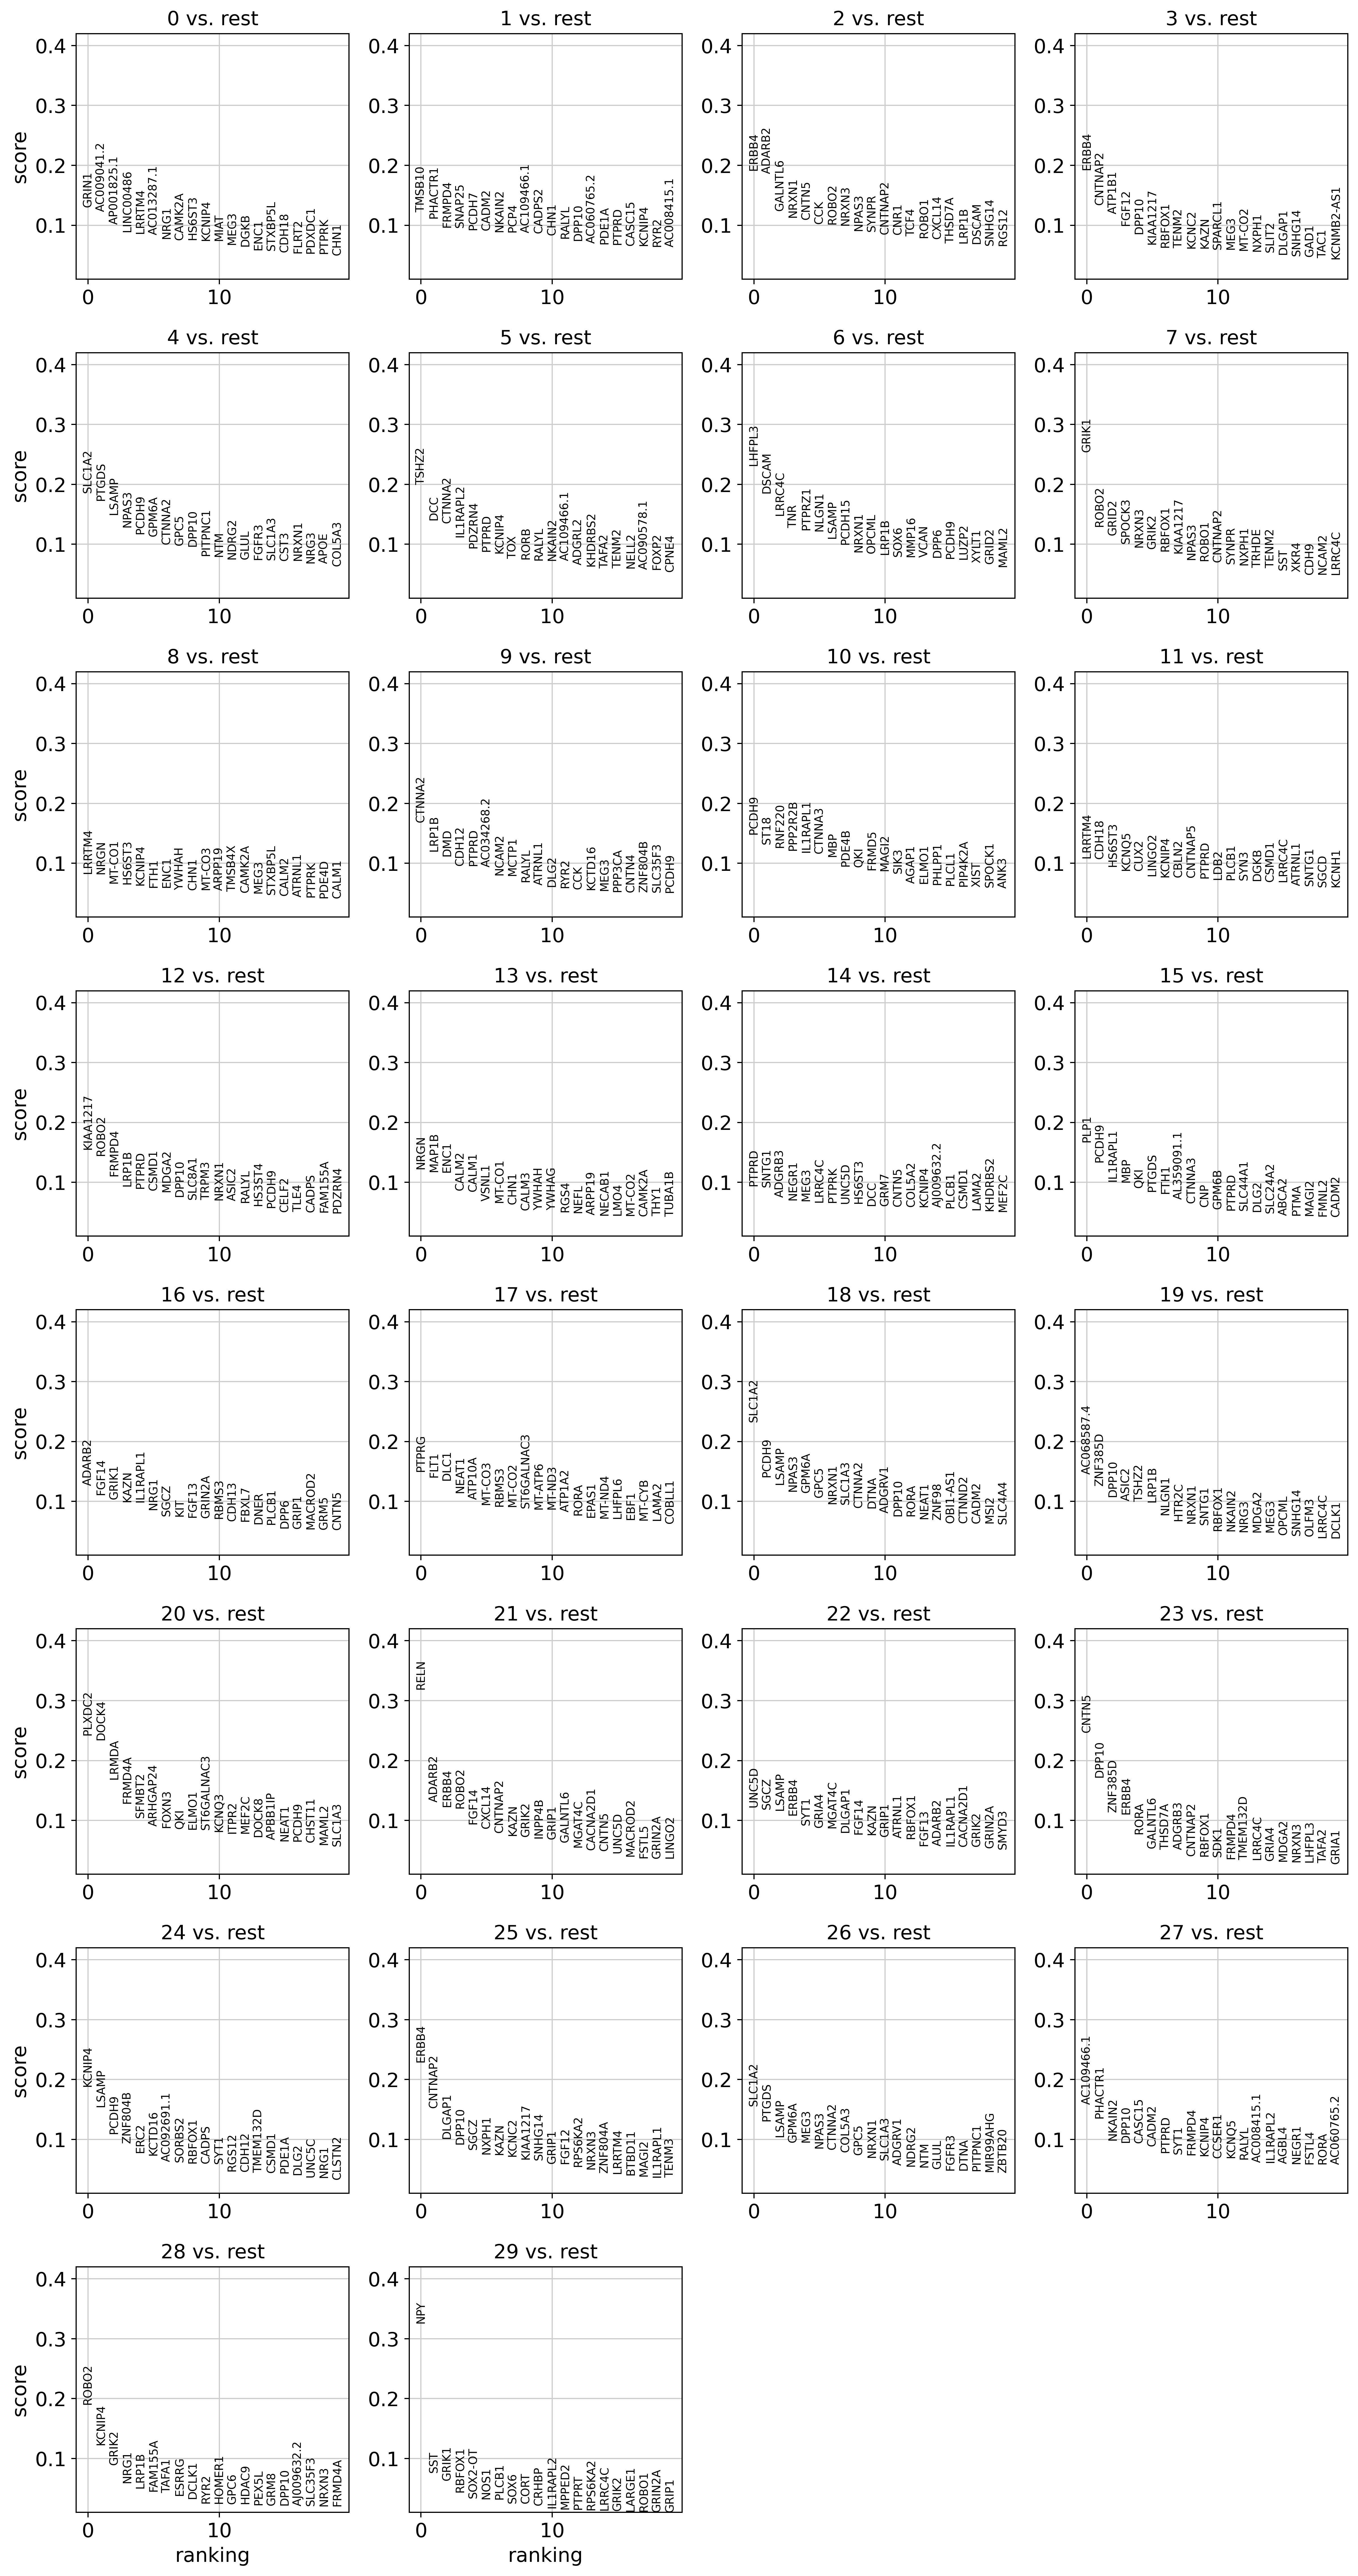

In [26]:
sc.pl.rank_genes_groups(adata, key='leiden')

In [27]:
# Query Omnipath and get PanglaoDB
markers = dc.get_resource("PanglaoDB")
markers

AttributeError: module 'decoupler' has no attribute 'get_resource'

In [ ]:
# Filter by canonical_marker and human
markers = markers[
    (markers["human"] == True) & (markers["canonical_marker"] == True)
]
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
1,CTRB1,True,Acinar cells,Endoderm,True,1.000000,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017
2,KLK1,True,Endothelial cells,Mesoderm,True,0.000000,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
5,KLK1,True,Principal cells,Mesoderm,True,0.000000,0.008145,True,0.285714,0.014058,9606,Kidney,0.013
6,KLK1,True,Acinar cells,Endoderm,True,0.833333,0.005031,True,0.314286,0.012826,9606,Pancreas,0.013
7,KLK1,True,Plasmacytoid dendritic cells,Mesoderm,True,0.000000,0.008202,True,1.000000,0.012914,9606,Immune system,0.013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8456,SLC14A1,True,Urothelial cells,Mesoderm,True,0.000000,0.018170,True,0.000000,0.000000,9606,Urinary bladder,0.008
8457,UPK3A,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000
8458,UPK1A,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000
8459,UPK2,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000


In [ ]:
# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]
markers["genesymbol_hs"] = [i.capitalize() for i in markers["genesymbol"]]
markers

<ipython-input-14-f2acaf468480>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markers["genesymbol_hs"] = [i.capitalize() for i in markers["genesymbol"]]


,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness,genesymbol_hs
1,CTRB1,True,Acinar cells,Endoderm,True,1.000000,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017,Ctrb1
2,KLK1,True,Endothelial cells,Mesoderm,True,0.000000,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013,Klk1
5,KLK1,True,Principal cells,Mesoderm,True,0.000000,0.008145,True,0.285714,0.014058,9606,Kidney,0.013,Klk1
6,KLK1,True,Acinar cells,Endoderm,True,0.833333,0.005031,True,0.314286,0.012826,9606,Pancreas,0.013,Klk1
7,KLK1,True,Plasmacytoid dendritic cells,Mesoderm,True,0.000000,0.008202,True,1.000000,0.012914,9606,Immune system,0.013,Klk1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8456,SLC14A1,True,Urothelial cells,Mesoderm,True,0.000000,0.018170,True,0.000000,0.000000,9606,Urinary bladder,0.008,Slc14a1
8457,UPK3A,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000,Upk3a
8458,UPK1A,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000,Upk1a
8459,UPK2,True,Urothelial cells,Mesoderm,True,0.000000,0.000000,True,0.000000,0.000000,9606,Urinary bladder,0.000,Upk2


In [ ]:
# Enrichment with Over Representation Analysis
dc.run_ora(
    mat=adata,
    net=markers,
    source="cell_type",
    target="genesymbol",
    min_n=3,
    verbose=False,
    use_raw=True,
)


# Object for visualizing the ORA-results
acts = dc.get_acts(adata, obsm_key="ora_estimate")
acts

AnnData object with n_obs × n_vars = 75628 × 108
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes', 'leiden'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pacmap', 'X_pca', 'X_umap', 'ora_estimate', 'ora_pvals'

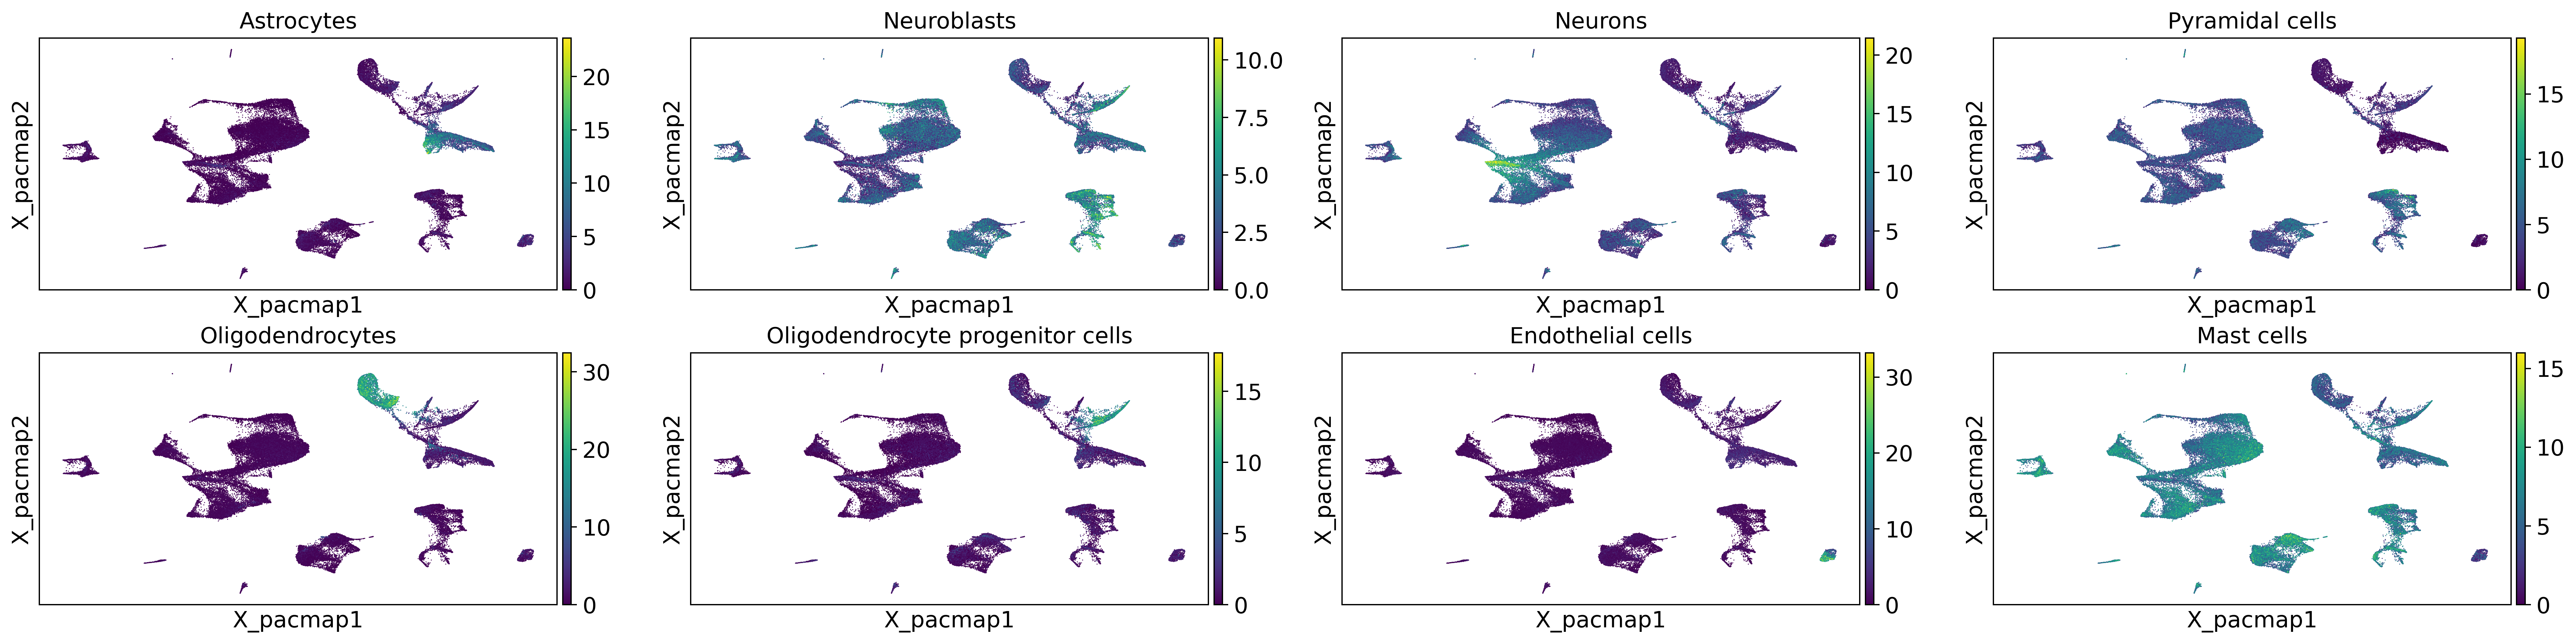

In [ ]:
with rc_context({'figure.figsize': (6, 3)}):
    sc.pl.embedding(
        acts,
        basis="X_pacmap",
        color=[
            "Astrocytes",
            "Neuroblasts",
            "Neurons",
            "Pyramidal cells",
            "Oligodendrocytes",
            "Oligodendrocyte progenitor cells",
            "Endothelial cells",
            "Mast cells"
        ],
        ncols=4
        )

In [ ]:
# Annotaiton
mean_enr = dc.summarize_acts(acts, groupby="leiden", min_std=1)
annotation_dict = dc.assign_groups(mean_enr)
annotation_dict

{'0': 'Mast cells',
 '1': 'Mast cells',
 '10': 'Neurons',
 '11': 'Mast cells',
 '12': 'Oligodendrocyte progenitor cells',
 '13': 'Mast cells',
 '14': 'Neurons',
 '15': 'Mast cells',
 '16': 'Oligodendrocytes',
 '17': 'Mast cells',
 '18': 'Mast cells',
 '19': 'Endothelial cells',
 '2': 'Mast cells',
 '20': 'Oligodendrocyte progenitor cells',
 '21': 'Neurons',
 '22': 'Mast cells',
 '23': 'Bergmann glia',
 '24': 'Mast cells',
 '25': 'Mast cells',
 '26': 'Oligodendrocytes',
 '27': 'Mast cells',
 '28': 'Pyramidal cells',
 '29': 'Mast cells',
 '3': 'Mast cells',
 '30': 'Mast cells',
 '31': 'Mast cells',
 '32': 'Mast cells',
 '33': 'Mast cells',
 '34': 'Astrocytes',
 '35': 'Mast cells',
 '36': 'Mast cells',
 '37': 'Oligodendrocyte progenitor cells',
 '38': 'Neurons',
 '4': 'Astrocytes',
 '5': 'Mast cells',
 '6': 'Mast cells',
 '7': 'Mast cells',
 '8': 'Mast cells',
 '9': 'Oligodendrocytes'}

In [ ]:
# Add cell type column based on annotation
adata.obs["ora_celltype"] = [
    annotation_dict[str(clust)] for clust in adata.obs["leiden"]
]

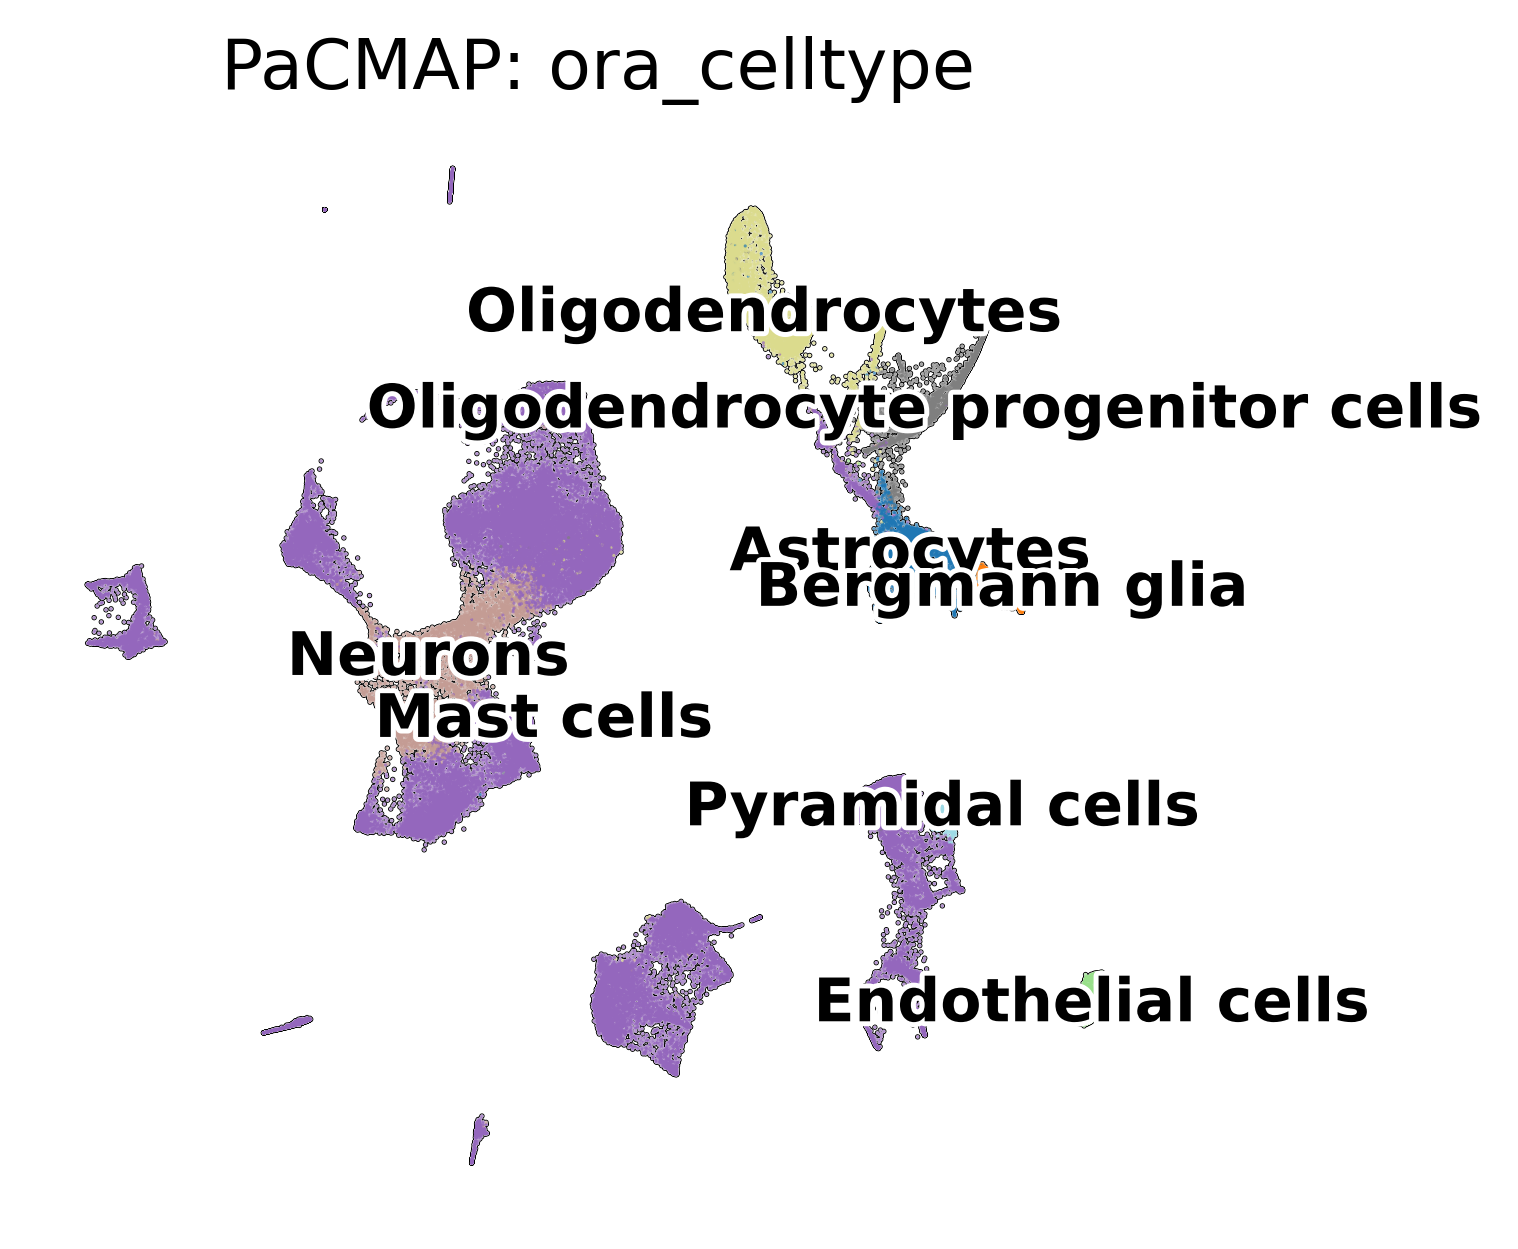

In [ ]:
sc.pl.embedding(
    adata,
    basis="X_pacmap",
    color="ora_celltype",
    title="PaCMAP: {feature}".format(feature="ora_celltype"),
    add_outline=True,
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False,
    palette="tab20",
)

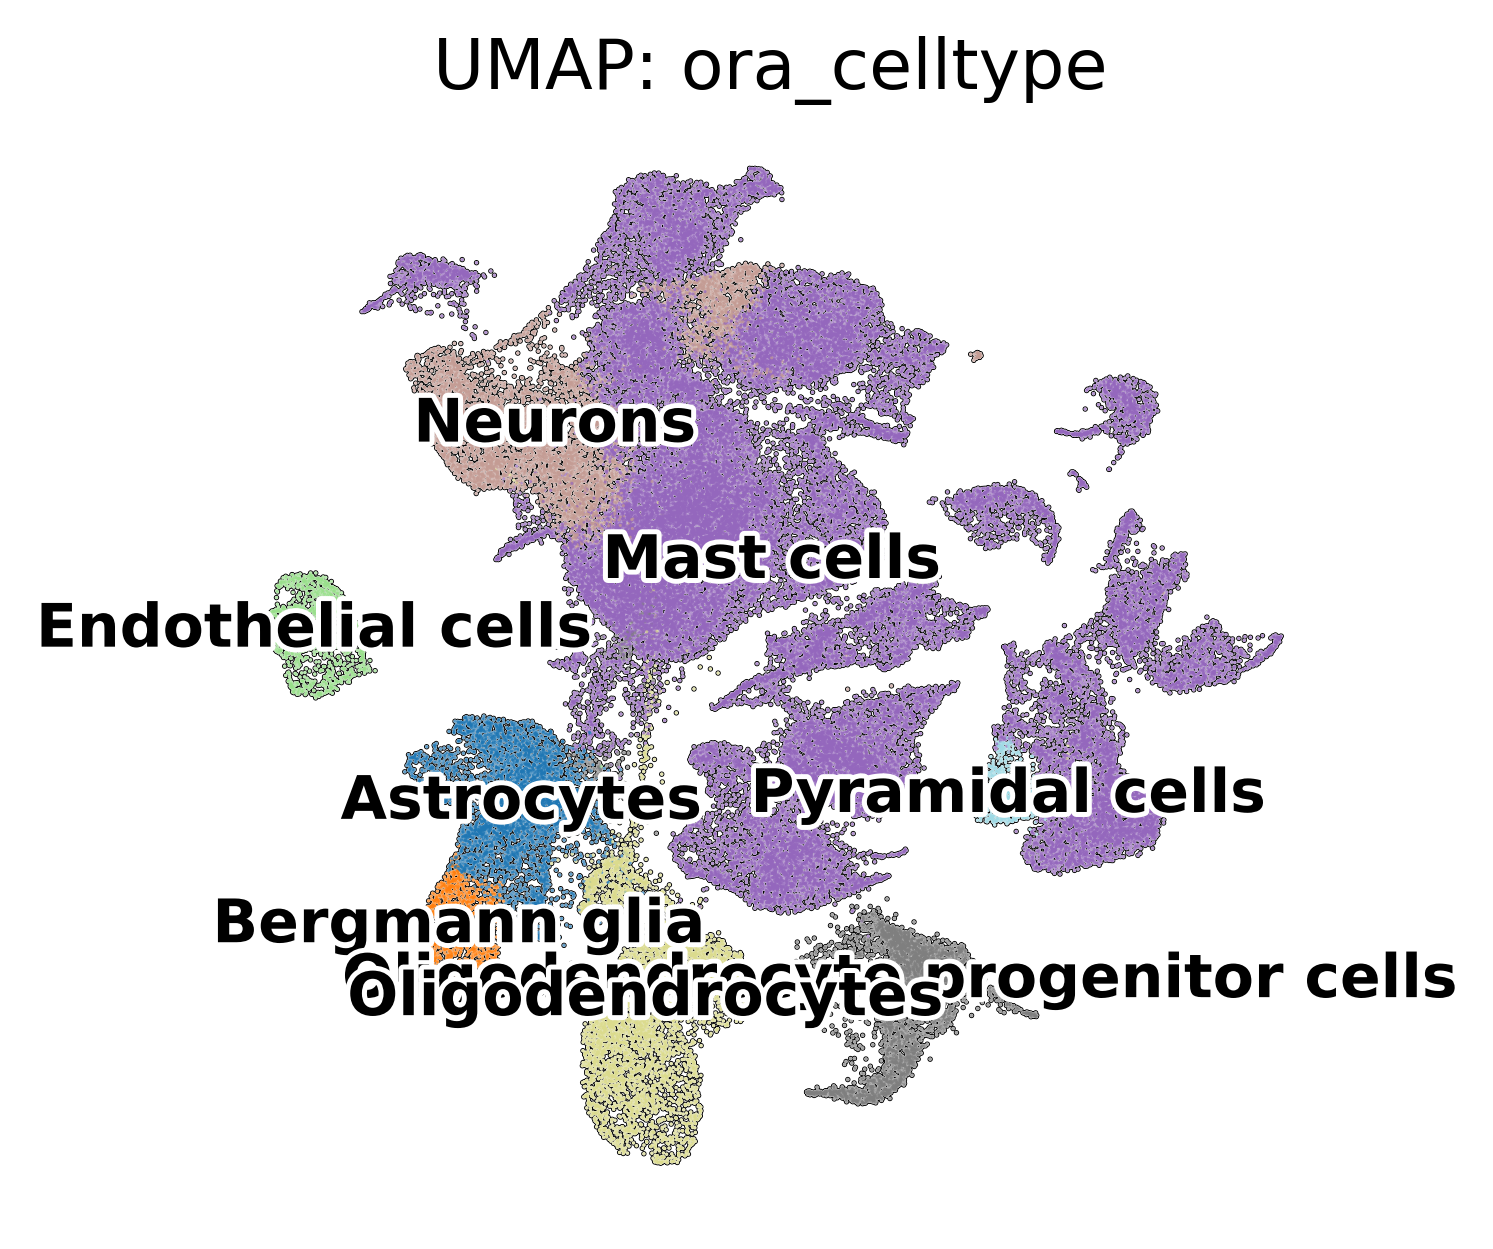

In [ ]:
sc.pl.umap(
    adata,
    color="ora_celltype",
    title="UMAP: {feature}".format(feature="ora_celltype"),
    add_outline=True,
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False,
    palette="tab20",
)

In [ ]:
#Investigate general distribution of male and female in cell with celltype==Neurons
neurons = adata[adata.obs["ora_celltype"] == "Neurons"]
neurons.obs.groupby("Sex")["cell_name"].count().reset_index()

<ipython-input-21-fe3125b1b1cd>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neurons.obs.groupby("Sex")["cell_name"].count().reset_index()


,Sex,cell_name
0,female,1330
1,male,5157


In [ ]:

#Filter to only keep cells that express the PVALB gene
gene_index = adata.var_names.get_loc('PVALB')
mask = adata.X[:, gene_index] > 0
only_pvalb_expressing_cells = adata[mask]

#Filter to only keep those PVALB expressing cells that are also of celltype==Neuron
only_ovalb_expressing_neurons = only_pvalb_expressing_cells[only_pvalb_expressing_cells.obs["ora_celltype"] == "Neurons"]


View of AnnData object with n_obs × n_vars = 2518 × 3189
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes', 'leiden', 'ora_celltype'
    var: 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization', 'neighbors', 'umap', 'leiden', 'ora_celltype_colors'
    obsm: 'X_pacmap', 'X_pca', 'X_umap', 'ora_estimate', 'ora_pvals'
    varm: 'PCs'
    layers: 'raw', 'sqrt_norm'
    obsp: 'distances', 'connectivities'

In [ ]:
#Group by condition and sex
cluster_condition_counts = only_ovalb_expressing_neurons.obs.groupby(["Sex",'Condition'])['cell_name'].count().reset_index()
cluster_condition_counts

<ipython-input-69-33e378a772ba>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_condition_counts = only_ovalb_expressing_neurons.obs.groupby(["Sex",'Condition'])['cell_name'].count().reset_index()


,Sex,Condition,cell_name
0,female,0,2
1,female,1,2
2,male,0,64
3,male,1,47
